# Per-Replicate ATAC-seq Heatmaps

In [1]:
import gzip, json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

# ── Paths (edit as needed) ───────────────────────────────────────────────
BASE = "/coh_labs/mvandenbrink/users/pkaur/6_tff1/2_bulk_atac/atacseq_pipeline/0_broadpeak"
MATRIX_FILE = os.path.join(BASE, "3_global_heatmap/global_per_replicate.mat.gz")
OUT_DIR = os.path.join(BASE, "4_per_replicate_heatmap")
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
# ── Read matrix ──────────────────────────────────────────────────────────
with gzip.open(MATRIX_FILE, "rt") as fh:
    header = json.loads(fh.readline().strip().lstrip("@"))
    rows = []
    for line in fh:
        fields = line.strip().split("\t")
        rows.append([float(v) if v != "nan" else np.nan for v in fields[6:]])

data = np.array(rows)
bounds = header["sample_boundaries"]
n_bins = bounds[1] - bounds[0]
sample_labels = header["sample_labels"]

print(f"Matrix shape: {data.shape}")
print(f"Sample boundaries: {bounds}")
print(f"Sample labels: {sample_labels}")
print(f"Bins per sample: {n_bins}")

Matrix shape: (6452, 2400)
Sample boundaries: [0, 400, 800, 1200, 1600, 2000, 2400]
Sample labels: ['GFP_REP1', 'GFP_REP2', 'GFP_REP3', 'TFF1_REP1', 'TFF1_REP2', 'TFF1_REP3']
Bins per sample: 400


In [3]:
# ── Parse samples into conditions ────────────────────────────────────────
# Auto-detect which samples belong to GFP vs TFF1 based on label names.
# Adjust the matching logic below if your labels differ.

n_samples = len(bounds) - 1
samples = {}
for i in range(n_samples):
    label = sample_labels[i]
    arr = np.nan_to_num(data[:, bounds[i]:bounds[i+1]], nan=0.0)
    samples[label] = arr

# Group into conditions
gfp_labels  = sorted([l for l in sample_labels if "GFP" in l.upper() or "gfp" in l.lower()])
tff1_labels = sorted([l for l in sample_labels if "TFF1" in l.upper() or "tff1" in l.lower()])

print(f"GFP replicates ({len(gfp_labels)}):  {gfp_labels}")
print(f"TFF1 replicates ({len(tff1_labels)}): {tff1_labels}")

# Sanity check
assert len(gfp_labels) > 0,  "No GFP samples found — check sample_labels"
assert len(tff1_labels) > 0, "No TFF1 samples found — check sample_labels"

GFP replicates (3):  ['GFP_REP1', 'GFP_REP2', 'GFP_REP3']
TFF1 replicates (3): ['TFF1_REP1', 'TFF1_REP2', 'TFF1_REP3']


In [4]:
# ── Shared sort order & color scale ──────────────────────────────────────
# Sort by mean of all GFP replicates (descending) — same order for both figures
gfp_mean = np.mean([samples[l] for l in gfp_labels], axis=0)
order = np.argsort(gfp_mean.mean(axis=1))[::-1]

# Global 99th percentile across ALL replicates for a shared color scale
all_vals = np.concatenate([samples[l].ravel() for l in sample_labels])
vmax = np.percentile(all_vals[all_vals > 0], 99) if (all_vals > 0).any() else 5.0

up, down = header["upstream"][0], header["downstream"][0]
x_kb = np.linspace(-up/1000, down/1000, n_bins)
n_peaks = data.shape[0]

print(f"Peaks: {n_peaks:,}  |  Bins: {n_bins}  |  vmax: {vmax:.4f}")

# Global y-limit for profile plots (shared across both figures)
prof_ymax = max(samples[l][order].mean(axis=0).max() for l in sample_labels) * 1.15
print(f"Profile y-max: {prof_ymax:.4f}")

Peaks: 6,452  |  Bins: 400  |  vmax: 0.1666
Profile y-max: 0.1390


In [22]:
# ── Plotting function ────────────────────────────────────────────────────

def plot_condition(rep_labels, condition_name, order, vmax, x_kb, n_peaks,
                   cmap="Purples", profile_color="black", prof_ymax=None):
    """
    Create a figure with one column per replicate.
    Each column has its own profile plot on top and heatmap below.
    """
    n_reps = len(rep_labels)

    # Width ratios: equal-width columns + thin colorbar
    width_ratios = [1] * n_reps + [0.15]
    fig = plt.figure(figsize=(1.3 * n_reps + 0.3, 3.5))
    gs = gridspec.GridSpec(
        2, n_reps + 1,
        height_ratios=[1.5, 5],
        width_ratios=width_ratios,
        hspace=0.08, wspace=0.5,
    )

    # Compute y-limits for profile plots (use passed-in value if available)
    all_mu = []
    for label in rep_labels:
        arr = samples[label][order]
        all_mu.append(arr.mean(axis=0))
    if prof_ymax is None:
        prof_ymax = max(m.max() for m in all_mu) * 1.15

    kw = dict(
        aspect="auto", cmap=cmap, vmin=0, vmax=vmax,
        extent=[x_kb[0], x_kb[-1], n_peaks, 0],
        interpolation="none",
    )

    im = None
    for idx, label in enumerate(rep_labels):
        arr = samples[label][order]
        mu = arr.mean(axis=0)
        se = arr.std(axis=0) / np.sqrt(n_peaks)

        # ── Individual profile plot ───────────────────────────────
        ax_prof = fig.add_subplot(gs[0, idx])
        ax_prof.fill_between(x_kb, mu - se, mu + se, color=profile_color, alpha=0.15)
        ax_prof.plot(x_kb, mu, color=profile_color, lw=1.2)
        ax_prof.set_xlim(x_kb[0], x_kb[-1])
        ax_prof.set_ylim(0, prof_ymax)
        ax_prof.tick_params(axis="x", bottom=False, labelbottom=False)

        # Title on each profile
        short = label.replace("_", " ")
        ax_prof.set_title(short, fontsize=7, pad=4)

        # Only leftmost gets y-tick labels
        if idx > 0:
            ax_prof.tick_params(axis="y", left=True, labelleft=False)
        else:
            ax_prof.tick_params(axis="y", labelsize=6)

        # ── Heatmap ───────────────────────────────────────────────
        ax = fig.add_subplot(gs[1, idx])
        im = ax.imshow(arr, **kw)
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.set_xticks([-2, 0, 2])
        ax.set_xticklabels(["-2kb", "0", "+2kb"], fontsize=7)

        if idx == 0:
            ax.set_ylabel(f"Peaks (n={n_peaks:,})", fontsize=8)

    # ── Suptitle ─────────────────────────────────────────────────
    fig.suptitle(condition_name, fontsize=11, fontweight="bold", y=1.02)

    # ── Colorbar ─────────────────────────────────────────────────
    cbar = fig.colorbar(im, cax=fig.add_subplot(gs[1, n_reps]))
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=6)

    return fig

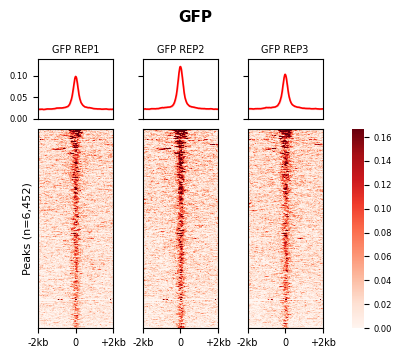

Saved GFP_per_replicate_heatmap.pdf


In [23]:
# ── GFP figure ───────────────────────────────────────────────────────────
%matplotlib inline

fig_gfp = plot_condition(
    gfp_labels, "GFP", order, vmax, x_kb, n_peaks,
    cmap="Reds", profile_color="Red", prof_ymax=prof_ymax,
)
plt.show()

for ext in ["pdf"]:
    fig_gfp.savefig(
        os.path.join(OUT_DIR, f"GFP_per_replicate_heatmap.{ext}"),
        dpi=300, bbox_inches="tight",
    )
    print(f"Saved GFP_per_replicate_heatmap.{ext}")

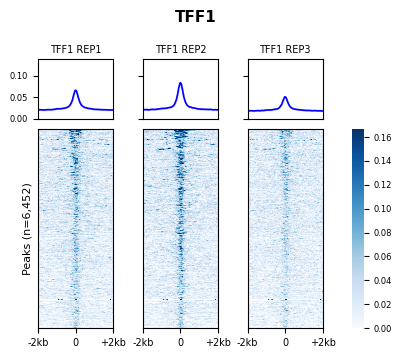

Saved TFF1_per_replicate_heatmap.pdf


In [24]:
# ── TFF1 figure ──────────────────────────────────────────────────────────
fig_tff1 = plot_condition(
    tff1_labels, "TFF1", order, vmax, x_kb, n_peaks,
    cmap="Blues", profile_color="Blue", prof_ymax=prof_ymax,
)
plt.show()

for ext in ["pdf"]:
    fig_tff1.savefig(
        os.path.join(OUT_DIR, f"TFF1_per_replicate_heatmap.{ext}"),
        dpi=300, bbox_inches="tight",
    )
    print(f"Saved TFF1_per_replicate_heatmap.{ext}")